In [36]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [37]:
# build vocabulary, mappings from chars to ints
# and ints to chars, ints are the indexes
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
print(type(words))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

<class 'list'>


In [38]:
from numpy import block
# build dataset
block_size = 3 # how many chars we sue t predict next one

def build_dataset(words):
    block_size = 3 # how many chars we sue t predict next one
    X, Y = [], []

    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [39]:
# utility function we will use for comparing manual gradient to autograd
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [40]:
vocab_size = 27
block_size = 3 # context length

n_embd = 10 # dimensionaltiy of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of MLP
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
# layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.1
# layer 2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size, generator=g)
# batch norm params
bngain = torch.randn((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.randn((1, n_hidden)) * 0.1


paramters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in paramters:
    p.requires_grad = True

In [41]:
# constrouct mini batch
n = batch_size
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]

In [46]:
#forward pass chunkated inot smaller steps that are posisble to backward one at a time

emb = C[Xb] # (batch_size, block_size, n_embd)
embcat = emb.view(emb.shape[0], -1) # flatten
# linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer activation
# batch norm layer 1
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*bndiff2.sum(0, keepdim=True)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# non-linearity
h = torch.tanh(hpreact)
# linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in paramters:
    p.grad = None
for t in [
    logprobs, probs, counts, counts_sum, counts_sum_inv, norm_logits,
          logit_maxes, logits, h, hpreact, bnraw, bnvar_inv, bnvar, bndiff2,
          bndiff, hprebn, embcat, emb, bnmeani]:
    t.retain_grad()
loss.backward()
loss

tensor(4.0622, grad_fn=<NegBackward0>)

In [53]:
# Excersize 1: backprop thru the whole thing manually,
# as defined in the forwrad pass above, one by one

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n

dprobs = (1.0 / probs) * dlogprobs
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
dcounts += torch.ones_like(counts) * dcounts_sum
dnorm_logits = counts * dcounts
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes


cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0


In [18]:
max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embedd the characters into vectors
    x = emb.view(emb.shape[0], -1) # flatten to a 1D vector
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # remove after debugging
    for p in paramters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in paramters:
        p.data += -lr * p.grad

    # track stats
    if i % 5000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/  20000: 2.4317
  10000/  20000: 2.1314


In [20]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    out = embcat
    for layer in layers:
        out = layer(out)
    loss = F.cross_entropy(out, y)
    print(split, loss.item())

# set eval mode BEFORE calling
for layer in layers:
    layer.training = False

split_loss('train')
split_loss('val')

# set back to train mode after
for layer in layers:
    layer.training = True

train 2.121527671813965
val 2.1602020263671875


In [21]:
g = torch.Generator().manual_seed(2147483647 + 10)

# switch to eval mode first
for layer in layers:
    layer.training = False

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(1, -1)
        for layer in layers:
            x = layer(x)
        probs = F.softmax(x, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

# switch back to training mode after
for layer in layers:
    layer.training = True

chriz.
fate.
harlin.
mili.
taty.
skanden.
jazhutn.
devir.
chiaeli.
nekahratchaihvon.
leigh.
ham.
port.
quint.
sulio.
alvin.
quisaelo.
dearyxirah.
euphrra.
mel.


layer 2 (      Tanh): mean +0.00, std 0.64, saturated: 5.97%
layer 5 (      Tanh): mean +0.00, std 0.67, saturated: 6.19%
layer 8 (      Tanh): mean -0.01, std 0.68, saturated: 5.72%
layer 11 (      Tanh): mean -0.00, std 0.69, saturated: 6.16%
layer 14 (      Tanh): mean -0.02, std 0.65, saturated: 2.72%


/tmp/ipykernel_3815/3311693972.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))


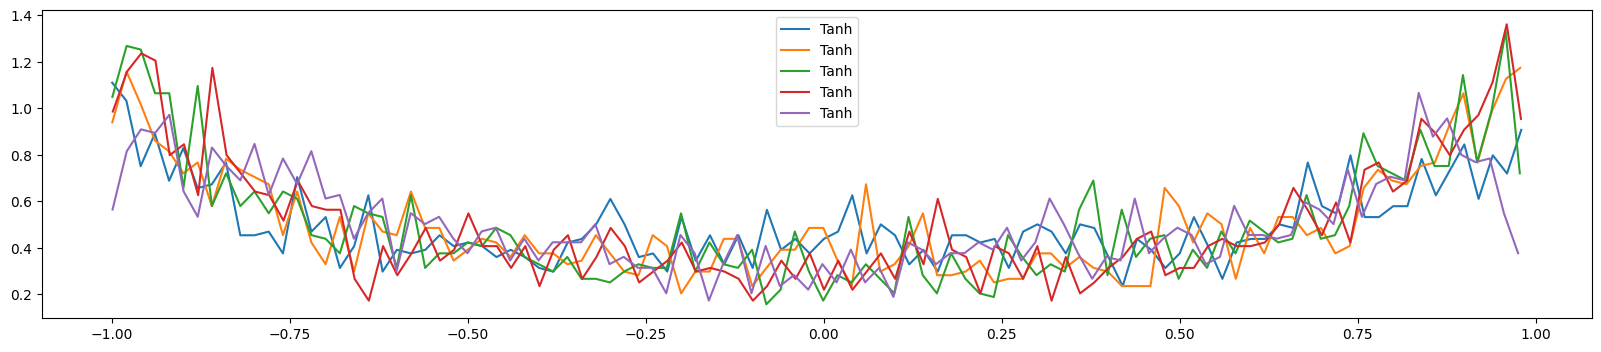

In [9]:
# vsiualize histograms
plt.figure(figsize=(20, 4)) # width and height
legends=[]
for i, layer in enumerate(layers[:-1]): # exclude output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach(), label=layer.__class__.__name__)
        legends.append(layer.__class__.__name__)
plt.legend(legends)

In [27]:
# class Linear:

#     def __init__(self, fan_in, fan_out, bias=True):
#         self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
#         self.bias = torch.zeros(fan_out) if bias else None

#     def __call__(self, x):
#         self.out = x @ self.weight
#         if self.bias is not None:
#             self.out += self.bias
#         return self.out

#     def parameters(self):
#         return [self.weight] + ([] if self.bias is None else [self.bias])

# class BatchNorm1d:

#     def __init__(self, dim, eps=1e-5, momentum=0.1):
#         self.eps = eps
#         self.momentum = momentum
#         self.training = True
#         # parameters (trained with backprop)
#         self.gamma = torch.ones(dim)
#         self.beta = torch.zeros(dim)
#         # buffers (trained with a running 'momentum update')
#         self.running_mean = torch.zeros(dim)
#         self.running_var = torch.ones(dim)

#     def __call__(self, x):
#         # calculate forward pass
#         if self.training:
#             xmean = x.mean(0, keepdim=True) # batch mean
#             xvar = x.var(0, keepdim=True) # batch variance
#         else:
#             xmean = self.running_mean
#             xvar = self.running_var
#         xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit var
#         self.out = self.gamma * xhat + self.beta
#         # update the buffers
#         if self.training:
#             with torch.no_grad():
#                 self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
#                 self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
#         return self.out

#     def parameters(self):
#         return [self.gamma, self.beta]

# class Tanh:

#     def __call__(self, x):
#         self.out = torch.tanh(x)
#         return self.out

#     def parameters(self):
#         return []

In [25]:
# vocab_size = 27
# block_size = 3 # context length
# batch_size = 32

# n_embd = 10 # dimensionaltiy of the character embedding vectors
# n_hidden = 100 # the number of neurons in the hidden layer of MLP
# g = torch.Generator().manual_seed(2147483647)

# C = torch.randn((vocab_size, n_embd), generator=g)
# layers = [
#     Linear(  n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
#     Linear(             n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
#     Linear(             n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
#     Linear(             n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
#     Linear(             n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
#     Linear(             n_hidden, vocab_size),
#     ]
# with torch.no_grad():
#     # last layer make less confident
#     layers[-1].weight *= 0.2
#     # all other layers apply gain
#     for layer in layers[:-1]:
#         if isinstance(layer, Linear):
#             layer.weight *= 5/3

# paramters = [C] + [p for layer in layers for p in layer.parameters()]
# for p in paramters:
#     p.requires_grad = True